In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Смотрим, что лежит в данных

In [11]:
file_path = "double_auction_2025-02-07.xlsx"
excel_file = pd.ExcelFile(file_path)

sheet_names = excel_file.sheet_names
sheet_names

['баллы', 'data', 'orders', 'trades', 'описание', 'В журнал']

In [12]:
data_df = excel_file.parse('data')
orders_df = excel_file.parse('orders')
trades_df = excel_file.parse('trades')

data_preview = data_df.head()
orders_preview = orders_df.head()
trades_preview = trades_df.head()

data_preview, orders_preview, trades_preview

(   participant.id_in_session participant.code participant.label  \
 0                          1         sjfdw7so     Седунова Анна   
 1                          2         jmccwp30   Болобаев Кирилл   
 2                          3         uvjzdzoe     Чемрова Диана   
 3                          4         31h7xgxn  Постников Стефан   
 4                          5         tzelf4rs    Моисеев Никита   
 
   participant._current_app_name participant.time_started_utc  \
 0                double_auction      2025-02-07 12:47:29.599   
 1                double_auction      2025-02-07 12:47:29.624   
 2                double_auction      2025-02-07 12:47:29.641   
 3                double_auction      2025-02-07 12:47:29.647   
 4                double_auction      2025-02-07 12:47:29.653   
 
    participant.payoff  player.id_in_group  player.role  player.payoff  \
 0                 543                   8          NaN            120   
 1                 188                   5        

### 1. Общий анализ рынка
#### 1.1 Анализ средней цены, количества сделок и распределения цен за каждый период

avg_price -- средняя цена по каждому раунду

total_trades -- количество сделок по раундам

min_price, max_price — минимальная и максимальная цена сделки в каждом раунде

In [13]:
trades_df.columns = trades_df.columns.str.lower()
orders_df.columns = orders_df.columns.str.lower()
data_df.columns = data_df.columns.str.lower()

market_summary = trades_df.groupby("round_number").agg(
    avg_price=("price", "mean"),
    total_trades=("price", "count"),
    min_price=("price", "min"),
    max_price=("price", "max")
).reset_index()

market_summary

,round_number,avg_price,total_trades,min_price,max_price
0,1,55.333333,15,45,85
1,2,64.000000,9,30,200
2,3,63.857143,7,51,75
3,4,55.727273,11,40,66
4,5,77.500000,14,71,90
5,6,59.250000,12,55,65
6,7,72.555556,9,50,95
7,8,76.333333,9,70,80
8,9,91.000000,10,79,110
9,10,80.333333,9,77,85


Распределение цен — построена гистограмма всех цен сделок (с kde-линией плотности)

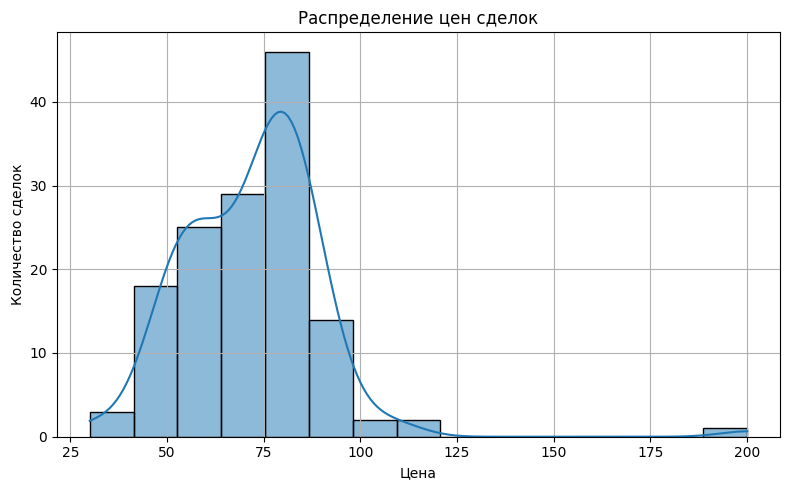

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(trades_df['price'], bins=15, kde=True)
plt.title('Распределение цен сделок')
plt.xlabel('Цена')
plt.ylabel('Количество сделок')
plt.grid(True)
plt.tight_layout()
plt.show()

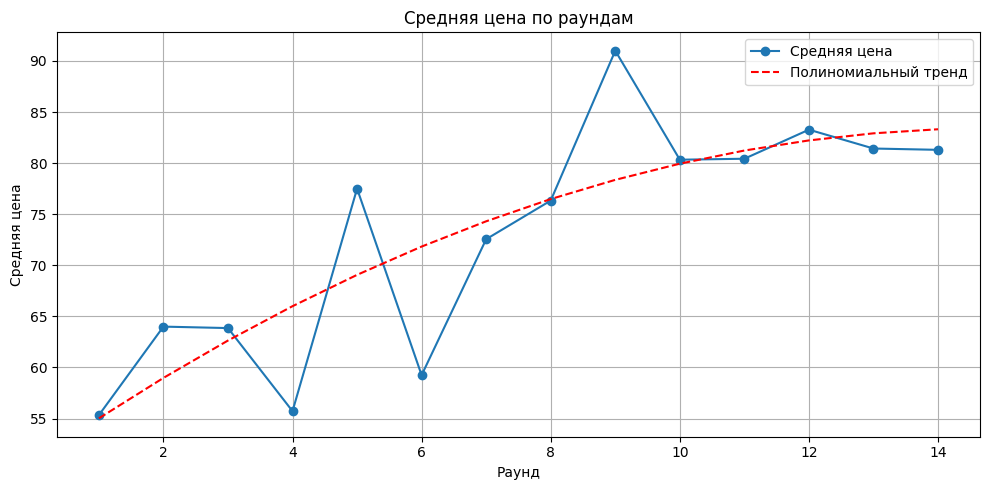

In [ ]:
x = market_summary['round_number']
y = market_summary['avg_price']

z = np.polyfit(x, y, 2)
p = np.poly1d(z)

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker='o', label='Средняя цена')
plt.plot(x, p(x), linestyle='--', color='red', label='Полиномиальный тренд')
plt.title('Средняя цена по раундам')
plt.xlabel('Раунд')
plt.ylabel('Средняя цена')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Наблюдается устойчивый рост средней цены в течение первых 10 раундов, затем — стабилизация

Полиномиальный тренд хорошо отражает адаптацию участников: изначально цены варьируются, но с ростом опыта рынок приближается к равновесной цене

Это может указывать на обучение стратегическому поведению со стороны продавцов и покупателей

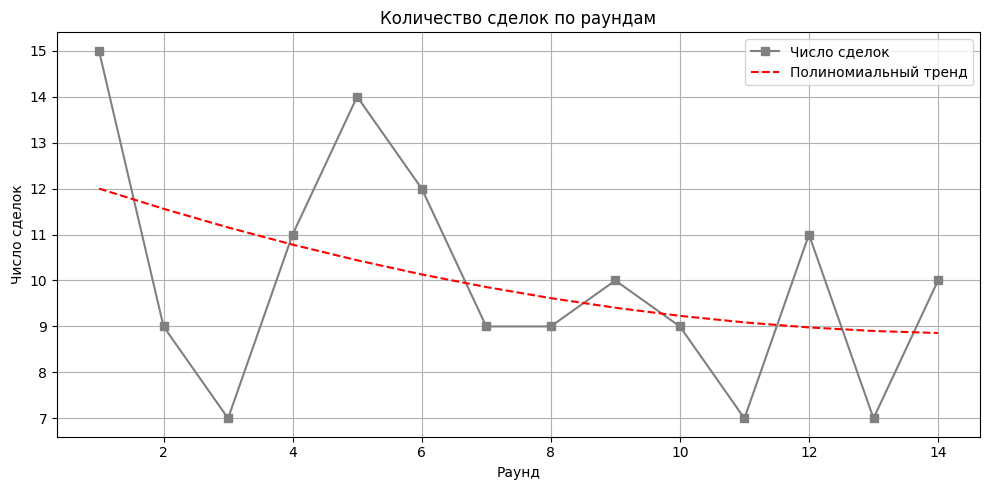

In [20]:
x = market_summary['round_number']
y = market_summary['total_trades']

z = np.polyfit(x, y, 2)
p = np.poly1d(z)

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker='s', color='gray', label='Число сделок')
plt.plot(x, p(x), linestyle='--', color='red', label='Полиномиальный тренд')
plt.title('Количество сделок по раундам')
plt.xlabel('Раунд')
plt.ylabel('Число сделок')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Общая тенденция — снижение объёма сделок, особенно после 6–7 раунда

Это может быть связано с:

- насыщением рынка (меньше агрессивных предложений)

- более избирательным поведением участников

- или приближением цен к точке, где спрос и предложение сбалансированы, но объём не максимален

Тренд подчёркивает сжатие активности на более зрелом этапе торгов

#### 1.2 Сравнить эти показатели между различными периодами, чтобы выявить тенденции и изменения

In [9]:
def assign_phase(round_number):
    if 1 <= round_number <= 6:
        return 'Phase 1 (Rounds 1–6)'
    elif 7 <= round_number <= 12:
        return 'Phase 2 (Rounds 7–12)'
    elif round_number >= 13:
        return 'Phase 3 (Rounds 13–18)'
    else:
        return 'Unknown'

# Добавляю разбиение на фазы
market_summary['phase'] = market_summary['round_number'].apply(assign_phase)

phase_comparison = market_summary.groupby('phase').agg(
    avg_price=('avg_price', 'mean'),
    std_price=('avg_price', 'std'),
    avg_trades=('total_trades', 'mean'),
    std_trades=('total_trades', 'std')
).reset_index()

print(phase_comparison)

                    phase  avg_price  std_price  avg_trades  std_trades
0    Phase 1 (Rounds 1–6)  62.611291   8.207447   11.333333    3.011091
1   Phase 2 (Rounds 7–12)  80.653920   6.297683    9.166667    1.329160
2  Phase 3 (Rounds 13–18)  81.364286   0.090914    8.500000    2.121320


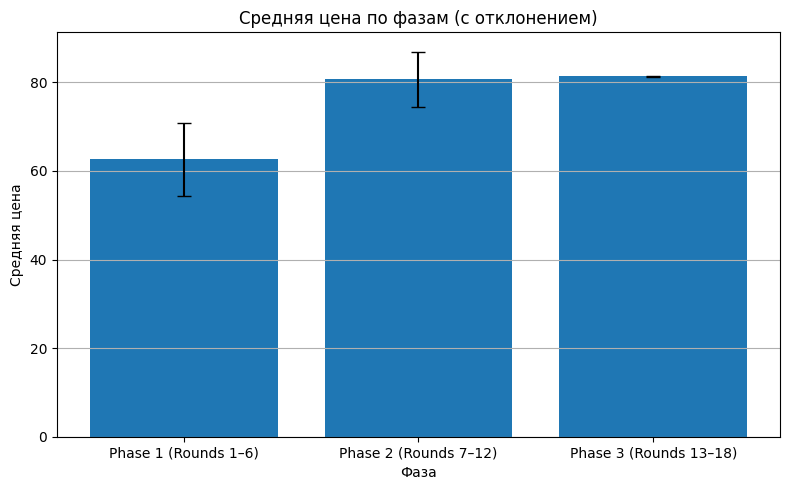

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(phase_comparison['phase'], phase_comparison['avg_price'], yerr=phase_comparison['std_price'], capsize=5)
plt.title('Средняя цена по фазам (с отклонением)')
plt.ylabel('Средняя цена')
plt.xlabel('Фаза')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

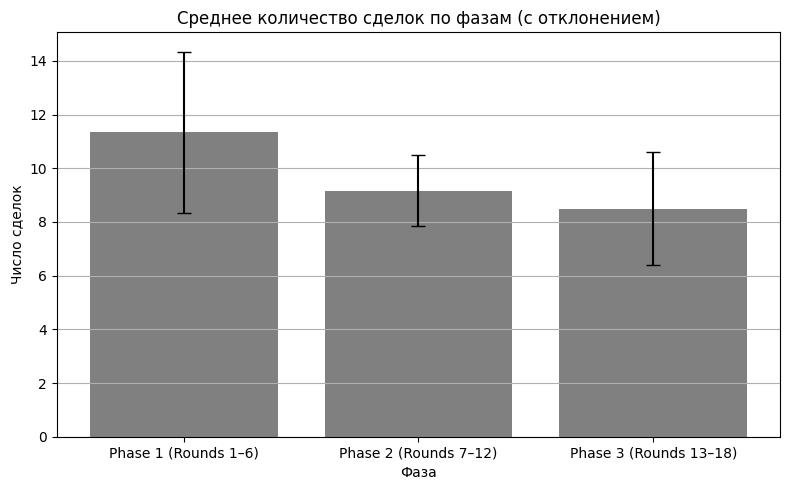

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(phase_comparison['phase'], phase_comparison['avg_trades'], yerr=phase_comparison['std_trades'], capsize=5, color='gray')
plt.title('Среднее количество сделок по фазам (с отклонением)')
plt.ylabel('Число сделок')
plt.xlabel('Фаза')
plt.grid(axis='y')
plt.tight_layout()
plt.show()